In [1]:
import sys
print(sys.executable)

C:\Users\caseh\Documents\bayesian-mmm-retail\.venv\Scripts\python.exe


In [2]:
import pymc_marketing
import pymc as pm
import arviz as az

print("pymc-marketing:", pymc_marketing.__version__)
print("pymc:", pm.__version__)
print("arviz:", az.__version__)

g++ not available, if using conda: `conda install gxx`


pymc-marketing: 1.0.0
pymc: 6.0.1
arviz: 1.3.0


In [3]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n_weeks = 130
dates = pd.date_range("2023-01-02", periods=n_weeks, freq="W-MON")

trend = np.linspace(0, 20, n_weeks)
yearly_seasonality = 10 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)
promo = rng.binomial(1, 0.15, n_weeks)

tv_spend = np.clip(50 + 20 * np.sin(2 * np.pi * np.arange(n_weeks) / 52 + 1) + rng.normal(0, 5, n_weeks), 0, None)
google_search_spend = np.clip(30 + rng.normal(0, 8, n_weeks), 0, None)
tiktok_spend = np.clip(15 + 0.1 * np.arange(n_weeks) + rng.normal(0, 4, n_weeks), 0, None)

print("Weeks:", n_weeks)
print("TV spend range:", tv_spend.min().round(2), "-", tv_spend.max().round(2))

Weeks: 130
TV spend range: 23.38 - 79.09


In [4]:
def geometric_adstock(x, alpha, l_max=8):
    weights = alpha ** np.arange(l_max)
    padded = np.concatenate([np.zeros(l_max - 1), x])
    return np.array([
        np.dot(padded[i:i + l_max][::-1], weights) / weights.sum()
        for i in range(len(x))
    ])

def logistic_saturation(x, lam):
    return (1 - np.exp(-lam * x)) / (1 + np.exp(-lam * x))

true_params = {
    "tv":     {"alpha": 0.6, "lam": 0.05, "beta": 1200},
    "search": {"alpha": 0.4, "lam": 0.08, "beta": 900},
    "tiktok": {"alpha": 0.3, "lam": 0.03, "beta": 700},
}

tv_effect = true_params["tv"]["beta"] * logistic_saturation(
    geometric_adstock(tv_spend, true_params["tv"]["alpha"]), true_params["tv"]["lam"])
search_effect = true_params["search"]["beta"] * logistic_saturation(
    geometric_adstock(google_search_spend, true_params["search"]["alpha"]), true_params["search"]["lam"])
tiktok_effect = true_params["tiktok"]["beta"] * logistic_saturation(
    geometric_adstock(tiktok_spend, true_params["tiktok"]["alpha"]), true_params["tiktok"]["lam"])

baseline = 2000
sales = (
    baseline + trend * 10 + yearly_seasonality * 20
    + 300 * promo + tv_effect + search_effect + tiktok_effect
    + rng.normal(0, 100, n_weeks)
)

df = pd.DataFrame({
    "date_week": dates,
    "tv_spend": tv_spend,
    "google_search_spend": google_search_spend,
    "tiktok_spend": tiktok_spend,
    "promo": promo,
    "trend": trend,
    "yearly_seasonality": yearly_seasonality,
    "sales": sales,
})
df.to_csv("../data/scenario_a/scenario_a_train.csv", index=False)
print(df.shape)
df["sales"].describe()

(130, 8)


count     130.000000
mean     4093.543660
std       318.496520
min      3431.694350
25%      3813.585554
50%      4153.546159
75%      4332.513729
max      4822.217968
Name: sales, dtype: float64

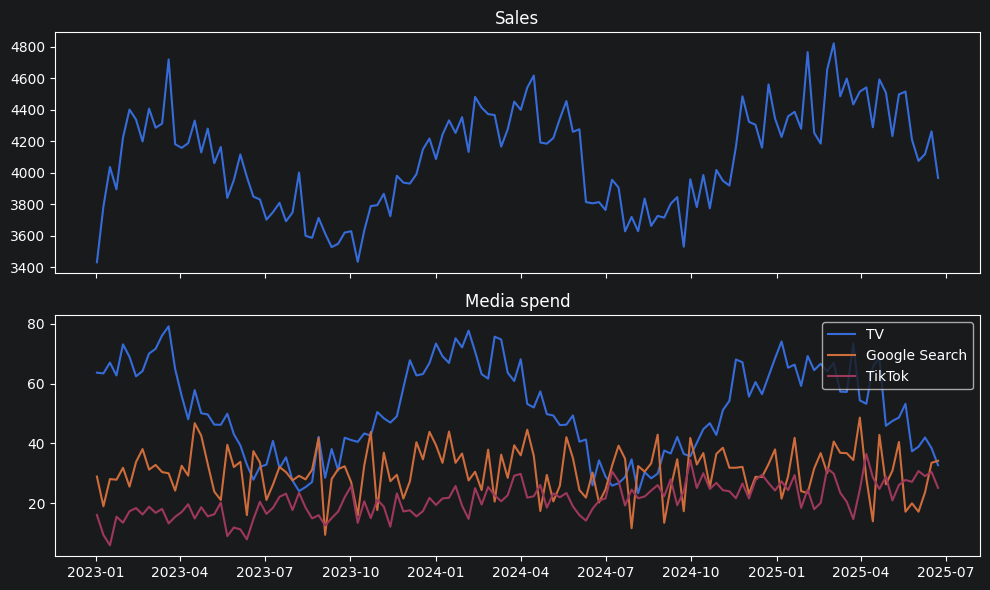

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(df["date_week"], df["sales"])
axes[0].set_title("Sales")
axes[1].plot(df["date_week"], df["tv_spend"], label="TV")
axes[1].plot(df["date_week"], df["google_search_spend"], label="Google Search")
axes[1].plot(df["date_week"], df["tiktok_spend"], label="TikTok")
axes[1].legend()
axes[1].set_title("Media spend")
plt.tight_layout()
plt.savefig("../figures/scenario_a/day1_spend_and_sales.png")
plt.show()

In [6]:
df_check = pd.read_csv("../data/scenario_a/scenario_a_train.csv", parse_dates=["date_week"])
print(df_check.shape)
print(df_check.dtypes)
print("Matches in-memory df:", df_check.equals(df))

(130, 8)
date_week              datetime64[us]
tv_spend                      float64
google_search_spend           float64
tiktok_spend                  float64
promo                           int64
trend                         float64
yearly_seasonality            float64
sales                         float64
dtype: object
Matches in-memory df: False


In [7]:
print("Nulls per column:\n", df.isnull().sum())
print("\nDuplicate weeks:", df["date_week"].duplicated().sum())
print("Date range:", df["date_week"].min(), "to", df["date_week"].max())
print("Weeks are 7 days apart:", (df["date_week"].diff().dropna().dt.days == 7).all())

spend_cols = ["tv_spend", "google_search_spend", "tiktok_spend"]
print("\nAny negative spend values:", (df[spend_cols] < 0).any().any())

Nulls per column:
 date_week              0
tv_spend               0
google_search_spend    0
tiktok_spend           0
promo                  0
trend                  0
yearly_seasonality     0
sales                  0
dtype: int64

Duplicate weeks: 0
Date range: 2023-01-02 00:00:00 to 2025-06-23 00:00:00
Weeks are 7 days apart: True

Any negative spend values: False


In [8]:
df[spend_cols + ["sales"]].describe()

,tv_spend,google_search_spend,tiktok_spend,sales
count,130.000000,130.000000,130.000000,130.000000
mean,51.280188,30.648114,21.213760,4093.543660
std,15.080111,7.876842,5.648776,318.496520
min,23.379162,9.466732,5.959586,3431.694350
25%,39.540704,25.631477,17.294384,3813.585554
50%,49.984981,31.327767,21.604250,4153.546159
75%,64.380627,36.195840,24.993187,4332.513729
max,79.088898,48.621225,36.481660,4822.217968


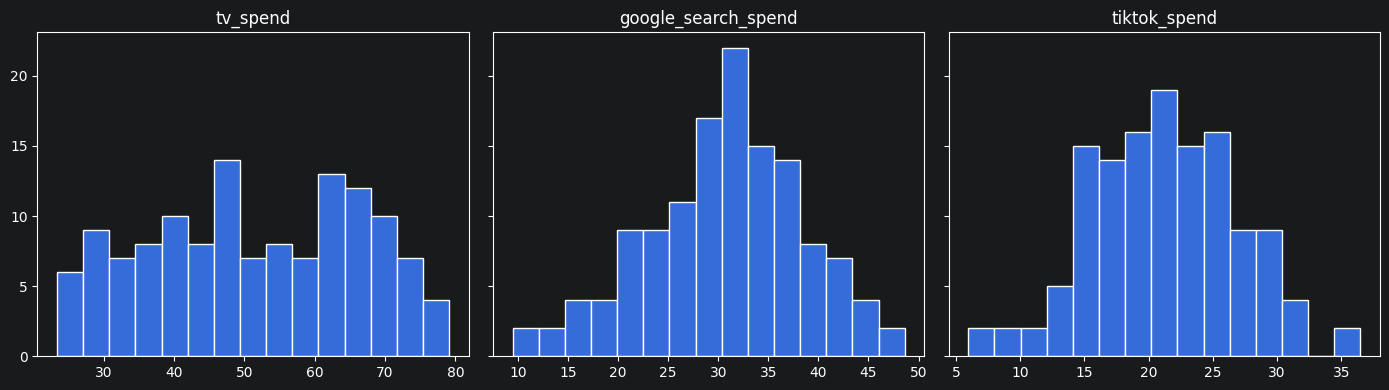

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, spend_cols):
    ax.hist(df[col], bins=15, edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../figures/scenario_a/day2_spend_histograms.png")
plt.show()

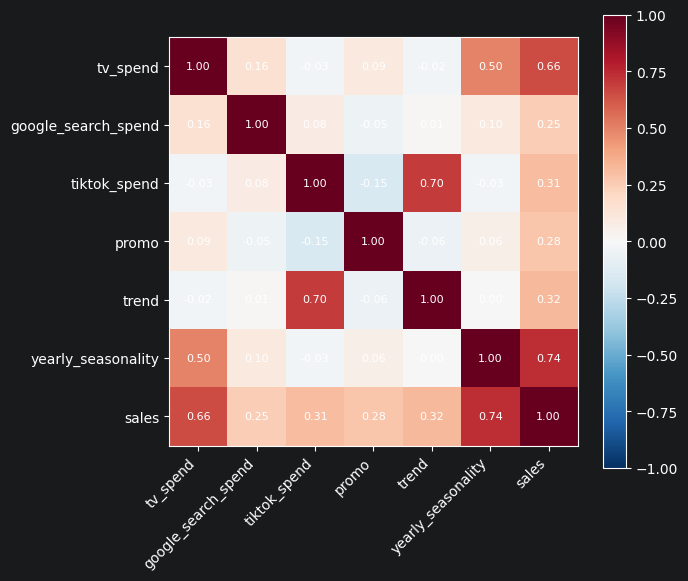

,tv_spend,google_search_spend,tiktok_spend,promo,trend,yearly_seasonality,sales
tv_spend,1.000000,0.156099,-0.028521,0.094980,-0.024177,0.495642,0.655798
google_search_spend,0.156099,1.000000,0.082436,-0.049104,0.012103,0.100864,0.249746
tiktok_spend,-0.028521,0.082436,1.000000,-0.149951,0.696669,-0.025039,0.309517
promo,0.094980,-0.049104,-0.149951,1.000000,-0.058069,0.059308,0.277683
trend,-0.024177,0.012103,0.696669,-0.058069,1.000000,0.002436,0.323940
yearly_seasonality,0.495642,0.100864,-0.025039,0.059308,0.002436,1.000000,0.741959
sales,0.655798,0.249746,0.309517,0.277683,0.323940,0.741959,1.000000


In [10]:
corr_cols = spend_cols + ["promo", "trend", "yearly_seasonality", "sales"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.savefig("../figures/scenario_a/day2_correlation_matrix.png")
plt.show()

corr

In [11]:
def acf(series, max_lag=20):
    series = series - series.mean()
    n = len(series)
    denom = np.sum(series**2)
    return np.array([np.sum(series[:n - lag] * series[lag:]) / denom for lag in range(max_lag + 1)])

sales_acf = acf(df["sales"].values, max_lag=20)
print("ACF at lag 0:", round(sales_acf[0], 3))
print("ACF at lag 1:", round(sales_acf[1], 3))
print("ACF at lag 10:", round(sales_acf[10], 3))
print("ACF at lag 20:", round(sales_acf[20], 3))

ACF at lag 0: 1.0
ACF at lag 1: 0.786
ACF at lag 10: 0.281
ACF at lag 20: -0.303


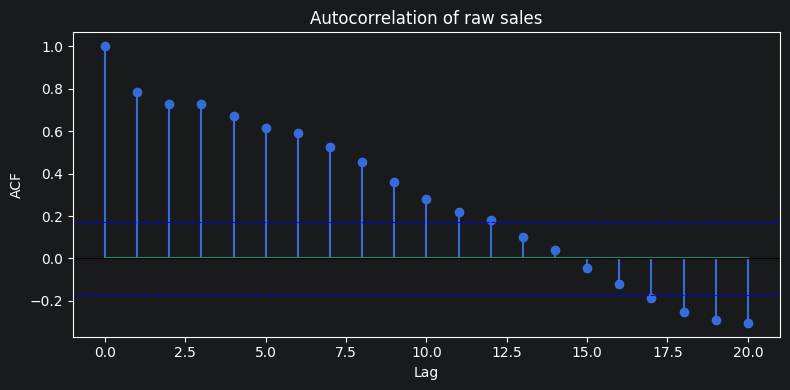

In [12]:
n = len(df)
ci = 1.96 / np.sqrt(n)

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(range(21), sales_acf)
ax.axhline(ci, color="blue", linestyle="--", linewidth=0.8)
ax.axhline(-ci, color="blue", linestyle="--", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_title("Autocorrelation of raw sales")
plt.tight_layout()
plt.savefig("../figures/scenario_a/day3_sales_acf.png")
plt.show()

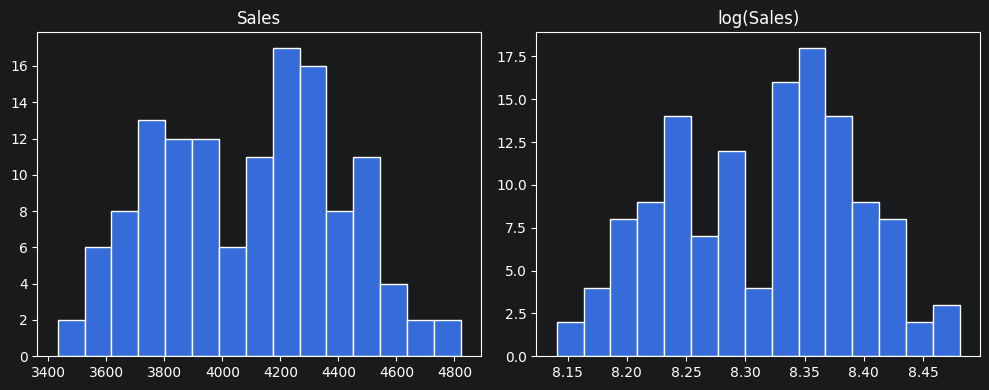

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["sales"], bins=15, edgecolor="white")
axes[0].set_title("Sales")
axes[1].hist(np.log(df["sales"]), bins=15, edgecolor="white")
axes[1].set_title("log(Sales)")
plt.tight_layout()
plt.savefig("../figures/scenario_a/day3_sales_distribution.png")
plt.show()

In [14]:
import json

true_params = {
    "tv":     {"alpha": 0.6, "lam": 0.05, "beta": 1200},
    "search": {"alpha": 0.4, "lam": 0.08, "beta": 900},
    "tiktok": {"alpha": 0.3, "lam": 0.03, "beta": 700},
    "baseline": 2000,
}

with open("../data/scenario_a/true_params.json", "w") as f:
    json.dump(true_params, f, indent=2)

print("Saved true_params.json")

Saved true_params.json
